<a href="https://colab.research.google.com/github/pranav-bhingarkar31/google-play-store-app-analysis/blob/main/PlayStore_App_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PlayStore App Review

# 🔷 📄 Project Summary
This project aims to analyze Google Play Store app data and user reviews to understand how applications across different categories perform and gain popularity. By examining ratings, installs, pricing, and user feedback, the project uncovers patterns that influence app success and user engagement.The analysis also focuses on identifying key factors that contribute to positive and negative user sentiment.

# 🔷 🎯 Problem Statement
To analyze Google Play Store data and identify:


* Factors affecting app ratings and installs
* Relationship between user sentiment and app performance
* Category-wise behavior of apps
* Differences between free and paid apps








# 🔷  Data Loading

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load datasets
apps_df = pd.read_csv('/content/drive/MyDrive/Data/Play Store Data.csv')
reviews_df = pd.read_csv('/content/drive/MyDrive/Data/User Reviews.csv')

# 🔷  Data Overview

In [3]:
print(apps_df.head())
print(reviews_df.head())



                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  \
0               Art & Design   January 7, 2018               1.0.0   
1  Art & Design;Pretend 

In [4]:
# Column names
print(apps_df.columns)
print(reviews_df.columns)


Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')
Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')


In [5]:

# Shape
print(apps_df.shape)
print(reviews_df.shape)

(10841, 13)
(64295, 5)


In [6]:
apps_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [7]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [8]:
apps_df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


# 🔷  Data Cleaning

Handle Missing Values

In [9]:
apps_df['Rating'].fillna(apps_df['Rating'].median(), inplace=True)
reviews_df = reviews_df.dropna(subset=['Translated_Review', 'Sentiment'])

/tmp/ipykernel_10359/2298049294.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  apps_df['Rating'].fillna(apps_df['Rating'].median(), inplace=True)


Clean Numeric Columns

In [10]:
# Installs
apps_df['Installs'] = apps_df['Installs'].astype(str)
apps_df['Installs'] = apps_df['Installs'].str.replace('+', '', regex=False)
apps_df['Installs'] = apps_df['Installs'].str.replace(',', '', regex=False)
apps_df['Installs'] = pd.to_numeric(apps_df['Installs'], errors='coerce')

# Reviews
apps_df['Reviews'] = pd.to_numeric(apps_df['Reviews'], errors='coerce')

# Size
apps_df['Size'] = apps_df['Size'].astype(str)
apps_df['Size'] = apps_df['Size'].str.replace('M', '', regex=False)
apps_df['Size'] = apps_df['Size'].str.replace('k', '', regex=False)
apps_df['Size'] = apps_df['Size'].replace('Varies with device', None)
apps_df['Size'] = pd.to_numeric(apps_df['Size'], errors='coerce')

# Price
apps_df['Price'] = apps_df['Price'].str.replace('$', '', regex=False)
apps_df['Price'] = pd.to_numeric(apps_df['Price'], errors='coerce')

# 🔷 Missing Values Summary

- The 'Rating' column contains a significant number of missing values, which were handled using median imputation.
- The reviews dataset had missing entries in 'Translated_Review' and 'Sentiment', which were removed as they are essential for sentiment analysis.

# 🔷  Merge the datasets

In [11]:
merged_df = pd.merge(apps_df, reviews_df, on='App', how='inner')

# 🔷 Feature Engineering

Install Groups

In [12]:
merged_df['Installs'] = merged_df['Installs'].astype(str)
merged_df['Installs'] = merged_df['Installs'].str.replace('+', '', regex=False)
merged_df['Installs'] = merged_df['Installs'].str.replace(',', '', regex=False)
merged_df['Installs'] = pd.to_numeric(merged_df['Installs'], errors='coerce')

merged_df = merged_df.dropna(subset=['Installs', 'Sentiment'])

merged_df['Install_Group'] = pd.cut(
    merged_df['Installs'],
    bins=[0, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9],
    labels=['0-10K','10K-100K','100K-1M','1M-10M','10M-100M','100M+']
)

Review Groups

In [13]:
merged_df['Reviews'] = pd.to_numeric(merged_df['Reviews'], errors='coerce')

merged_df['Review_Group'] = pd.cut(
    merged_df['Reviews'],
    bins=[0, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8],
    labels=['0-1K','1K-10K','10K-100K','100K-1M','1M-10M','10M+']
)

# 🔷 📊 Exploratory Data Analysis (EDA)

1. Do higher-rated apps get more positive sentiment?

In [14]:
merged_df.groupby('Rating')['Sentiment'].value_counts()

Rating  Sentiment
2.6     Negative     24
        Neutral      22
        Positive     16
2.7     Negative     56
        Positive     38
                     ..
4.8     Negative     58
        Neutral      30
4.9     Positive     91
        Neutral       4
        Negative      3
Name: count, Length: 66, dtype: int64

📊 Observation:

* Higher-rated apps generally show more positive sentiment
* Some high-rated apps still receive negative reviews


💡 Insight:


* Ratings indicate overall satisfaction, but sentiment captures detailed user opinions.

2. Which categories have most negative reviews?

Text(0.5, 1.0, 'Category vs Sentiment')

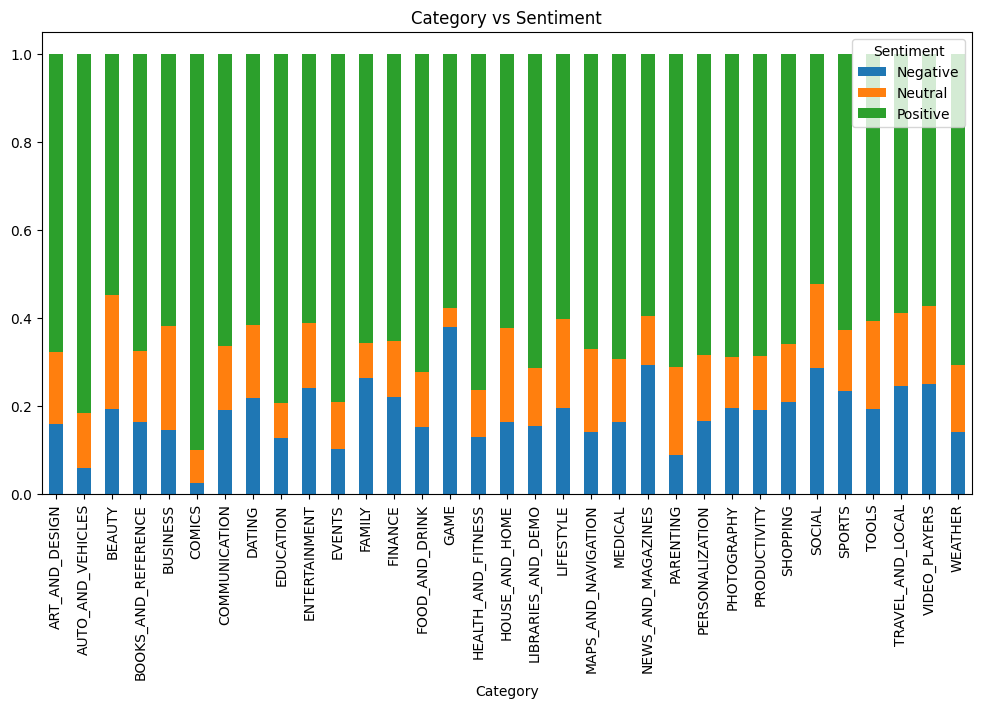

In [15]:
pd.crosstab(
    merged_df['Category'],
    merged_df['Sentiment'],
    normalize='index'
).plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Category vs Sentiment")

📊 Observation:

* Tools, Games, and Communication categories show higher negative sentiment

💡 Insight:

* High-usage categories attract more criticism

3. Do free apps get worse reviews than paid apps?

Text(0.5, 1.0, 'Free vs Paid App Sentiment')

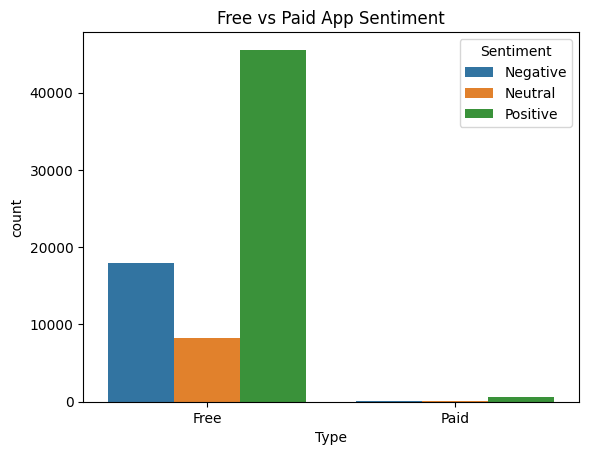

In [16]:
sns.countplot(x='Type', hue='Sentiment', data=merged_df)
plt.title("Free vs Paid App Sentiment")

📊 Observation:



* Free apps show more mixed sentiment
* Paid apps show slightly more consistent positive sentiment





💡 Insight:

* Free apps attract more users → more diverse opinions

4. Do apps with more installs have better sentiment?

Text(0.5, 1.0, 'Installs vs Sentiment')

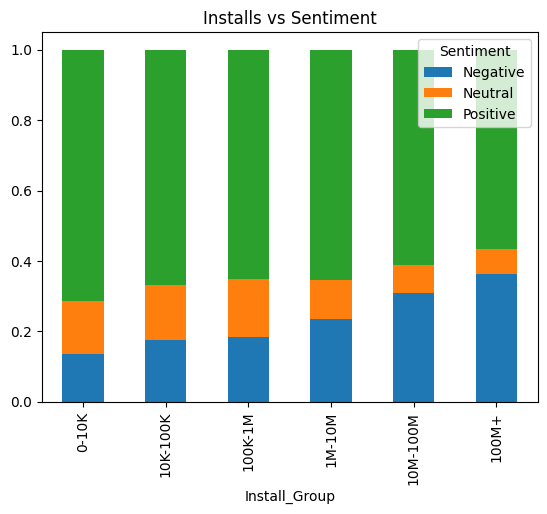

In [17]:
pd.crosstab(
    merged_df['Install_Group'],
    merged_df['Sentiment'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title("Installs vs Sentiment")

📊 Observation:

* Low install apps → more positive sentiment
* High install apps → more negative feedback


💡 Insight:

* Larger user base → higher expectations → more criticism

5. Do paid apps have better user sentiment?

In [18]:
pd.crosstab(
    merged_df['Type'],
    merged_df['Sentiment'],
    normalize='index'
)

Sentiment,Negative,Neutral,Positive
Type,,,
Free,0.250895,0.114643,0.634462
Paid,0.145780,0.053708,0.800512


 📊 Observation:

Paid apps show slightly better sentiment


💡 Insight:

Paying users expect quality and are more selective

6. Which app categories receive the most negative feedback?

In [19]:
pd.crosstab(
    merged_df['Category'],
    merged_df['Sentiment'],
    normalize='index'
).sort_values(by='Negative', ascending=False)

Sentiment,Negative,Neutral,Positive
Category,,,
GAME,0.380131,0.042562,0.577307
NEWS_AND_MAGAZINES,0.293103,0.110708,0.596189
SOCIAL,0.286123,0.191702,0.522175
FAMILY,0.263790,0.078342,0.657868
VIDEO_PLAYERS,0.250755,0.175227,0.574018
TRAVEL_AND_LOCAL,0.245082,0.166720,0.588197
ENTERTAINMENT,0.241677,0.147554,0.610769
SPORTS,0.234304,0.137557,0.628139
FINANCE,0.220010,0.126929,0.653061


📊 Observation:


* Tools and Games rank highest in negative sentiment



💡 Insight:

* Competitive categories face more user scrutiny

7. Do user ratings match review sentiment?

In [20]:
merged_df.groupby('Rating')['Sentiment'].value_counts(normalize=True)

Rating  Sentiment
2.6     Negative     0.387097
        Neutral      0.354839
        Positive     0.258065
2.7     Negative     0.430769
        Positive     0.292308
                       ...   
4.8     Negative     0.155080
        Neutral      0.080214
4.9     Positive     0.928571
        Neutral      0.040816
        Negative     0.030612
Name: proportion, Length: 66, dtype: float64

📊 Observation:

* Ratings and sentiment are somewhat aligned
* Not always consistent






💡 Insight:



* Ratings are averages, sentiment shows detailed feedback

8. Which apps have highest negative sentiment?

Text(0.5, 1.0, 'Top 10 Apps with Most Negative Reviews')

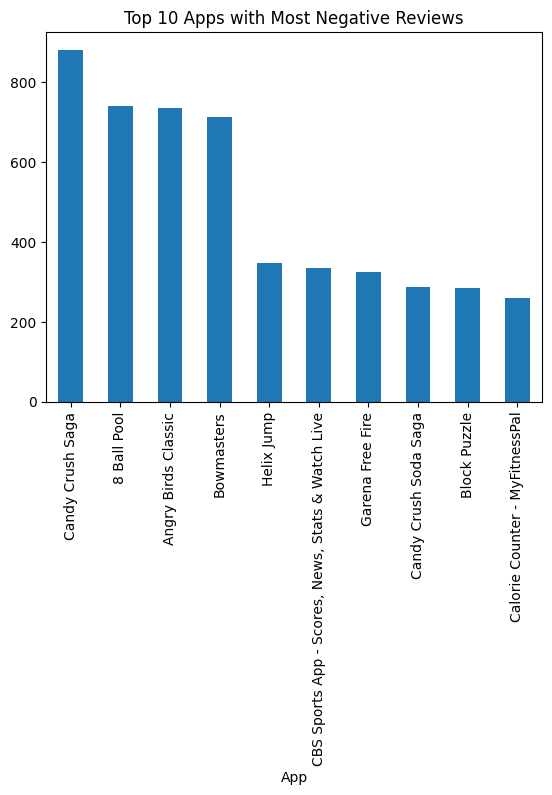

In [21]:
top_neg = merged_df[merged_df['Sentiment'] == 'Negative']['App'].value_counts().head(10)

top_neg.plot(kind='bar')
plt.title("Top 10 Apps with Most Negative Reviews")

📊 Observation:

* Popular apps dominate negative feedback


💡 Insight:

* More users → more feedback → more complaints

9. Do apps with more reviews get more negative feedback?

Text(0.5, 1.0, 'Reviews vs Sentiment')

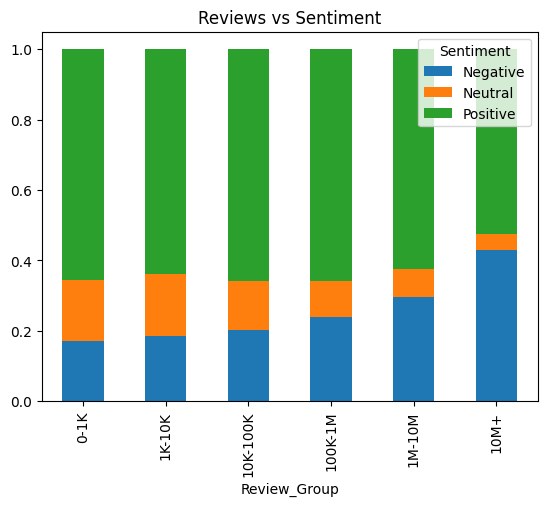

In [22]:
pd.crosstab(
    merged_df['Review_Group'],
    merged_df['Sentiment'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title("Reviews vs Sentiment")

📊 Observation:


* Higher review count → more negative sentiment


💡 Insight:


*  Larger audience → more diverse opinions

# 🔷 📊 Additional Analysis

1. Rating Distribution

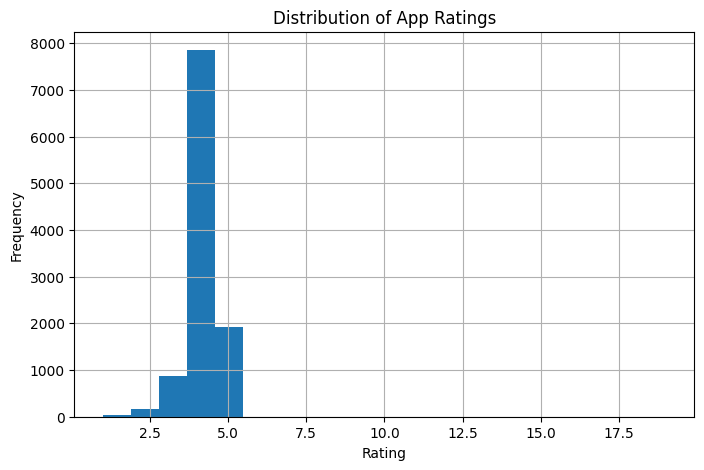

In [23]:
plt.figure(figsize=(8,5))
apps_df['Rating'].hist(bins=20)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

Category vs Rating

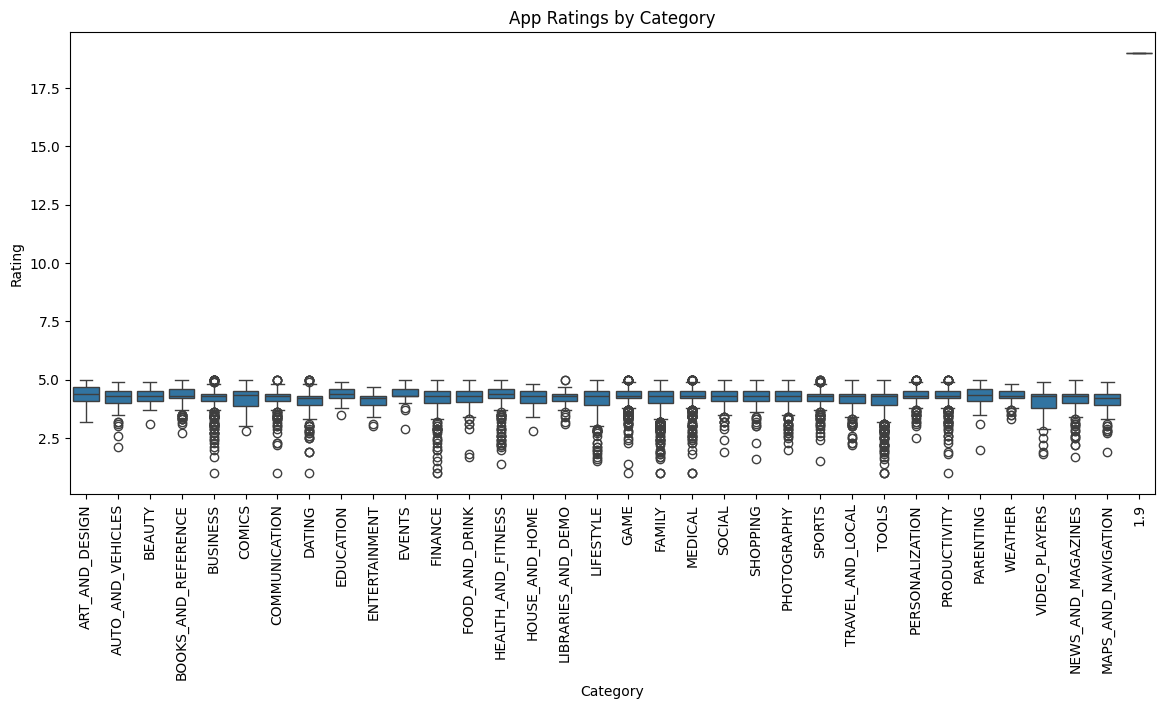

In [24]:
plt.figure(figsize=(14,6))
sns.boxplot(x='Category', y='Rating', data=apps_df)

plt.xticks(rotation=90)
plt.title("App Ratings by Category")
plt.xlabel("Category")
plt.ylabel("Rating")

plt.show()

3. Installs vs Rating

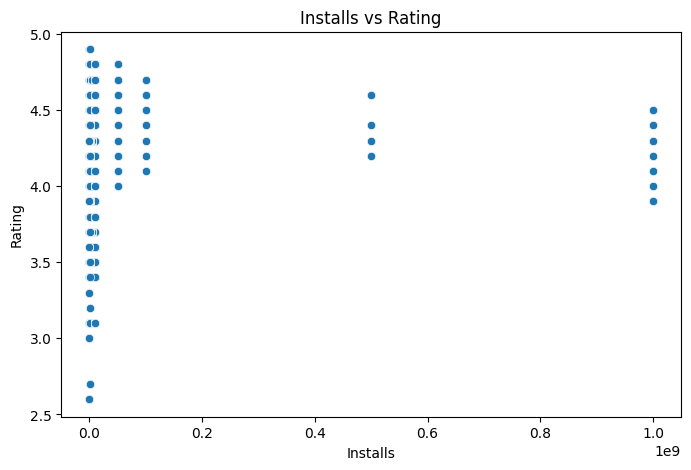

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Installs', y='Rating', data=merged_df)

plt.title("Installs vs Rating")
plt.xlabel("Installs")
plt.ylabel("Rating")

plt.show()

4. Sentiment Distribution

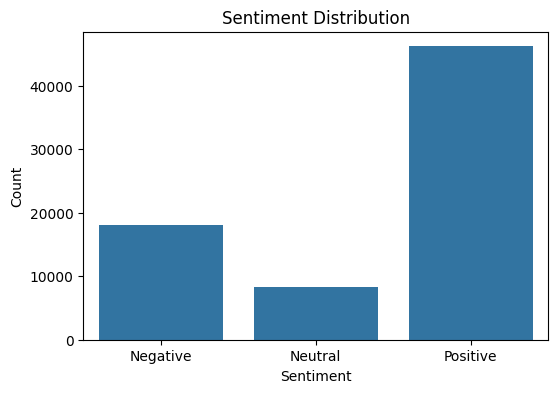

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment', data=merged_df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

5. Correlation Heatmap

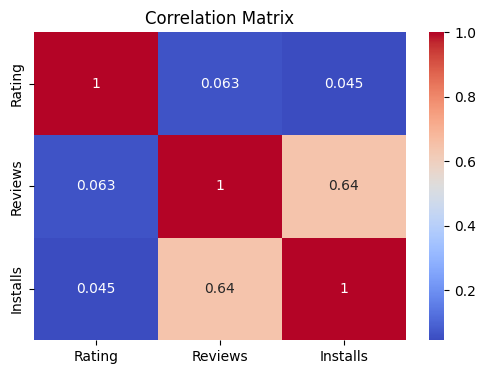

In [27]:
plt.figure(figsize=(6,4))

sns.heatmap(
    apps_df[['Rating','Reviews','Installs']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

# 🔷 📌 Final Conclusion

- App performance is influenced by both ratings and user sentiment, but ratings alone do not fully capture user experience.
- High-install apps tend to receive more diverse and critical feedback due to larger user bases.
- Free apps dominate the platform but show more variability in user sentiment compared to paid apps.
- Categories such as Tools and Games exhibit higher negative sentiment, indicating competitive and high-expectation environments.
- User sentiment becomes increasingly critical as app popularity grows, highlighting the importance of continuous user experience improvement.

# 🔷 💼 Business Recommendations

- Focus on improving user experience for high-install apps, as larger audiences lead to increased scrutiny and feedback.
- Implement strong feedback monitoring systems to quickly identify and address negative sentiment trends.
- Do not rely solely on ratings; incorporate sentiment analysis for a deeper understanding of user satisfaction.
- Free apps should prioritize quality and performance optimization to manage diverse user expectations.
- Categories with consistently high negative sentiment present opportunities for innovation and differentiation.

# 🔷 📌 Key Takeaways

- More users ≠ better sentiment → popularity increases criticism
- Ratings ≠ true user experience → sentiment gives deeper insights
- Free apps ≠ better perception → they face higher variability
- Category matters → user expectations differ across domains

# 🔷 📌 Limitations of the Analysis

- Sentiment analysis is based on available review data and may not represent all users.
- Missing data and data cleaning steps may introduce slight bias.
- Ratings and sentiment may vary over time and are not static indicators.